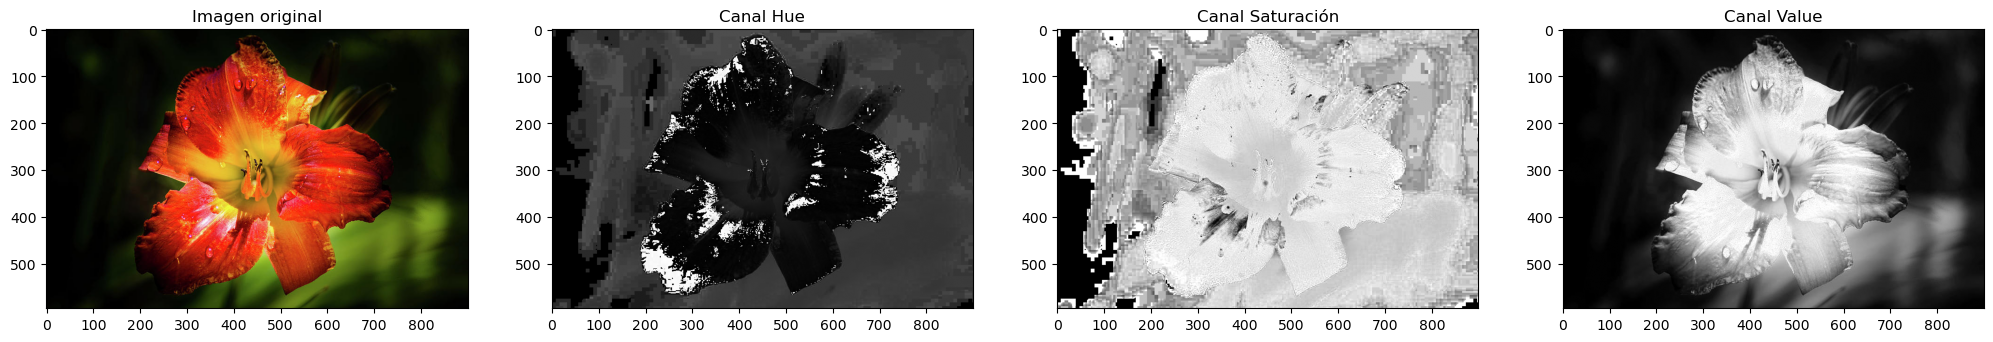

In [9]:
import cv2
import matplotlib.pyplot as plt 
import numpy as np

imagen1 = cv2.imread('pego.png')
img = cv2.cvtColor(imagen1, cv2.COLOR_BGR2RGB)

def RGB2HSV(img):
    img = img.astype(np.float32)
    img = img / 255
    new_img = np.zeros_like(img)

    maxChanel = np.argmax(img, axis=2)
    maxValue = np.amax(img, axis=2)
    minValue = np.amin(img, axis=2)

    # Value
    new_img[...,2] = maxValue

    # Saturación
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j] == 0:
                new_img[i,j,1] = 0
            else:
                new_img[i,j,1] = (maxValue[i,j] - minValue[i,j]) / maxValue[i,j]

    # Hue
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            if maxValue[i,j] == minValue[i,j]:
                new_img[i,j,0] = 0
            elif maxChanel[i,j] == 0:  # R
                new_img[i,j,0] = 60 * ((img[i,j,1] - img[i,j,2]) / (maxValue[i,j] - minValue[i,j]))
            elif maxChanel[i,j] == 1:  # G
                new_img[i,j,0] = 120 + 60 * ((img[i,j,2] - img[i,j,0]) / (maxValue[i,j] - minValue[i,j]))
            elif maxChanel[i,j] == 2:  # B
                new_img[i,j,0] = 240 + 60 * ((img[i,j,0] - img[i,j,1]) / (maxValue[i,j] - minValue[i,j]))

    # Ajustar negativos
    new_img[...,0][new_img[...,0] < 0] += 360

    return new_img


hsv_img = RGB2HSV(img)

fig, axs = plt.subplots(1,4,figsize=(25,10))

axs[0].imshow(img)
axs[0].set_title('Imagen original')

axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')

axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturación')

axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')

plt.show()

Text(0.5, 1.0, 'Canal Value')

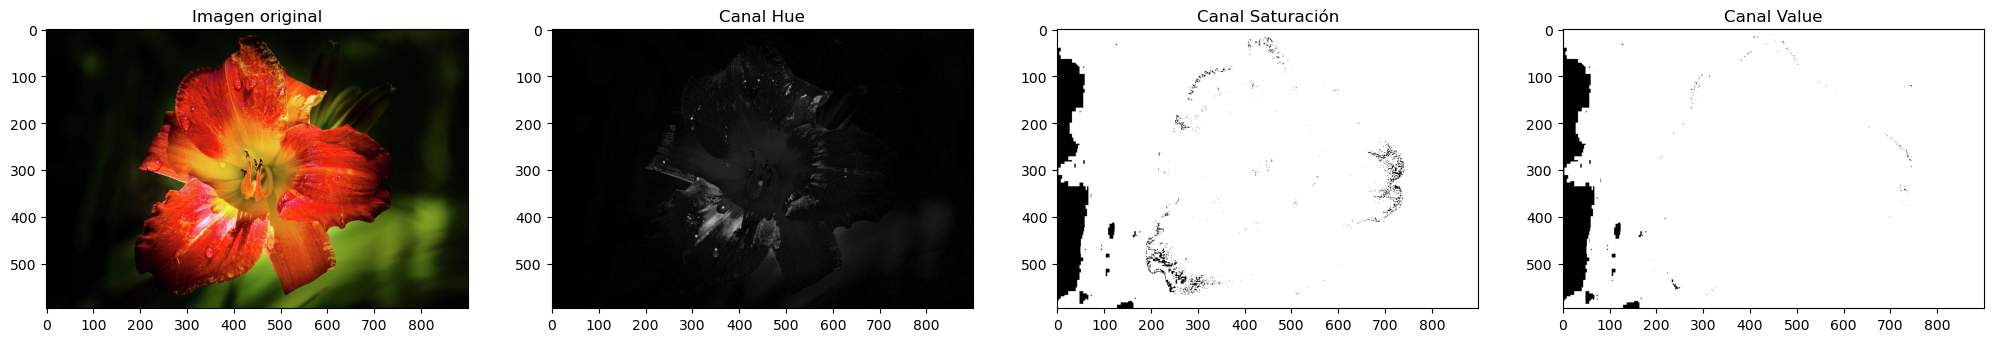

In [13]:
hsv_img_cv2=cv2.cvtColor(img,cv2.COLOR_RGB2BGR)
fig, axs = plt.subplots(1,4,figsize=(25,10))

axs[0].imshow(img)
axs[0].set_title('Imagen original')

axs[1].imshow(hsv_img[...,0], cmap='gray', vmin=0, vmax=360)
axs[1].set_title('Canal Hue')

axs[2].imshow(hsv_img[...,1], cmap='gray', vmin=0, vmax=1)
axs[2].set_title('Canal Saturación')

axs[3].imshow(hsv_img[...,2], cmap='gray', vmin=0, vmax=1)
axs[3].set_title('Canal Value')


Text(0.5, 1.0, 'Imagen 2')

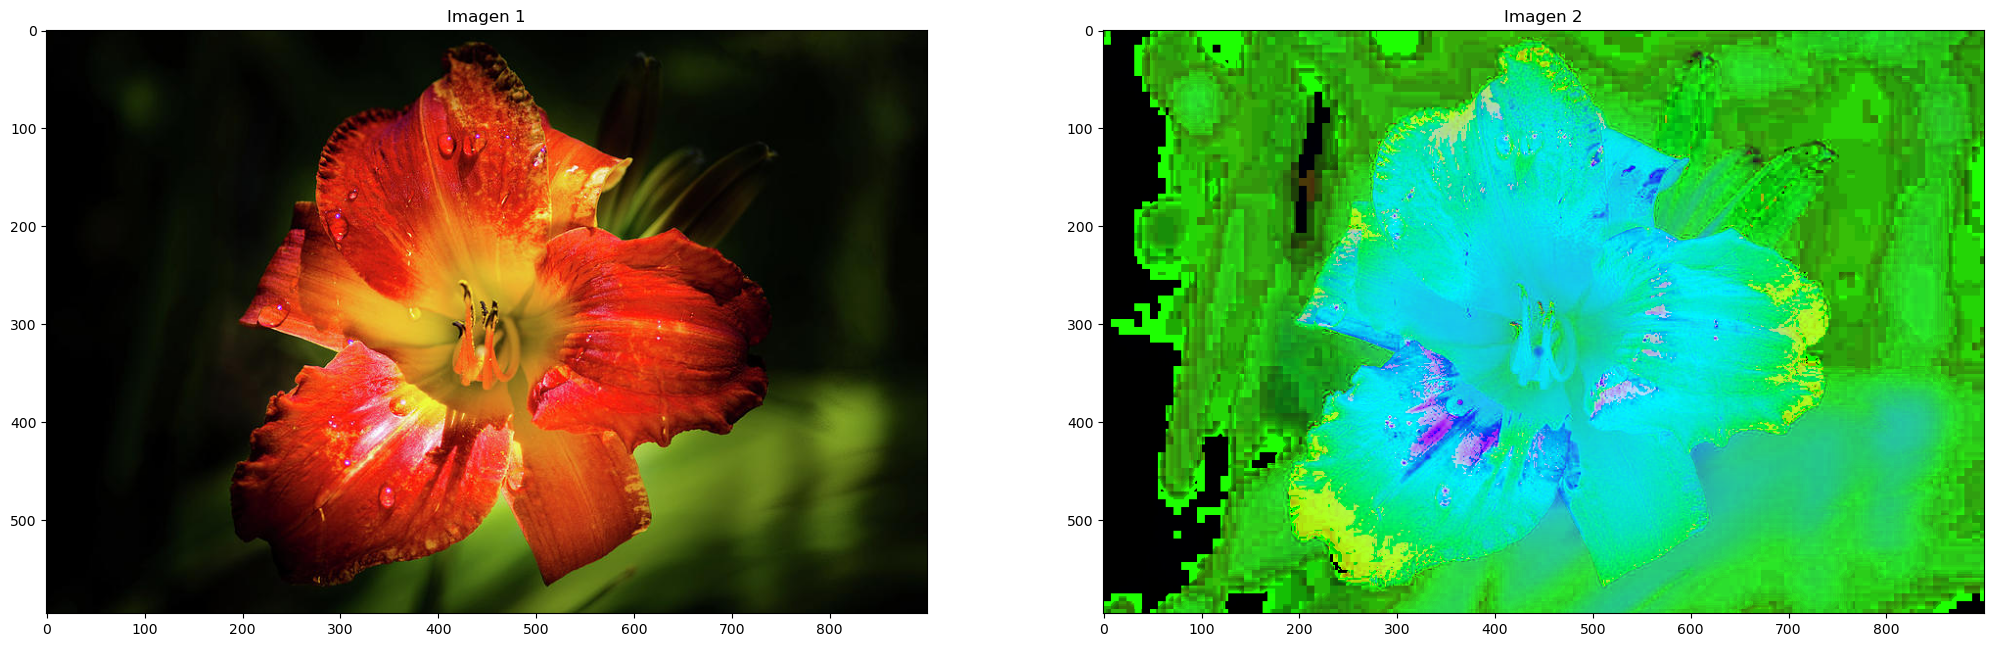

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt 

img_rgb=cv2.cvtColor(cv2.imread('pego.png',cv2.IMREAD_COLOR),cv2.COLOR_BGR2RGB)

img_hsv=cv2.cvtColor(img_rgb,cv2.COLOR_RGB2HSV)
fig, axs = plt.subplots(1,2,figsize=(25,10))
axs[0].imshow(img_rgb)
axs[0].set_title('Imagen 1')
axs[1].imshow(img_hsv)
axs[1].set_title('Imagen 2')



